# CS4168 Data Mining — Project Section 3.3
## Classification: Predicting Popularity Category

Binary classification of Spotify tracks: is each track's `popularity` score above the dataset median?

**Workflow**:

1. Load and clean the data (drop rows missing the target, drop duplicate tracks).
2. Lean classification-focused EDA.
3. Binarise the target on the median; drop the original `popularity` column (per spec).
4. Build a `ColumnTransformer`-based preprocessing pipeline.
5. Stratified 80 / 20 train / test split.
6. Single `DecisionTreeClassifier` as a high-variance baseline (foil for Random Forest).
7. Three tuned candidates — **Random Forest, k-NN, Gaussian Naïve Bayes** — tuned via 10-fold CV with F1 as the refit metric.
8. Compare candidates on six metrics; select the winner.
9. Sensitivity check: re-evaluate the winner *without* `track_genre`.
10. Final test-set evaluation (used once).
11. Feature importance (permutation; tree-based aggregated by parent feature where applicable).
12. Save the trained model.
13. Discussion.

## Design choices and justifications

| Decision | Choice | Reason |
|---|---|---|
| Missing values | Drop the 40 rows with NaNs | All 40 rows are missing the *target* (`popularity`) and several predictors. We can't impute a label. 2% data loss. |
| Duplicate `track_id` | Drop (keep first) | Same song appearing in both train and test would leak labels — the test set is supposed to be unseen data, not data the model has already memorised. |
| `track_genre` as feature | Keep, plus a sensitivity check | Spec §3.2 explicitly drops genre for *clustering*; §3.3 does not. We test how much of the predictive power comes from genre alone. |
| Target binarisation | `popularity > median(popularity)` on the full cleaned data | Spec §3.3 wording. Median is computed pre-split — this is a target *definition*, not feature engineering, so the leak is one scalar. |
| Preprocessing | Group-wise `ColumnTransformer`: OneHot for nominal categoricals, `RobustScaler` for outlier-prone numerics, `StandardScaler` for [0,&nbsp;1] audio features, passthrough for binary | Audio features have heterogeneous scales / distributions; a single scaler can't be appropriate for all of them. |
| Models | Random Forest + k-NN + Gaussian NB | Three distinct ML paradigms — bagging ensemble, instance-based, probabilistic-generative — covering different bias-variance behaviours. |
| CV strategy | `StratifiedKFold(10, shuffle=True, random_state=42)` | Stratified 10-fold is the standard CV protocol: balances bias-variance trade-off in the error estimate while keeping class proportions per fold. |
| Primary metric | F1-score (multi-metric reporting) | Classes are near-balanced, so F1 is threshold-dependent at 0.5 (matches what `predict()` does) and rejects models with extreme precision / recall asymmetry. ROC-AUC and AP are reported alongside. |
| Train/test split | 80 / 20, stratified, `random_state=42` | Standard split ratio; stratification preserves the class balance in both partitions. |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate,
    cross_val_predict,
    cross_val_score,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import permutation_importance
from sklearn.base import clone
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, precision_recall_curve, average_precision_score,
)
from sklearn import set_config
import pickle

set_config(display="diagram")
RANDOM_STATE = 42
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid")

## 1. Load and clean

In [2]:
df = pd.read_csv("../data/tracks2026.csv")
print("Raw shape:", df.shape)
df.head()

Raw shape: (2000, 17)


,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5xmO5SbFOiVrRGrMQhL4Jk,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,5cF0dROlMOK5uNZtivgu50,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,4OQ9XGe11ckizN2EBnNED2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,6Grw9OtoslF9JrDJ6pgsQG,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,3fGpNiwYr981n72YY4DZvB,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop


In [3]:
# Cast `explicit` from bool to int (0/1).
df["explicit"] = df["explicit"].astype(int)

# Missing values per column
df.isna().sum()

track_id             0
popularity          40
duration_ms          0
explicit             0
danceability        40
energy              40
key                  0
loudness            39
mode                 0
speechiness          0
acousticness         0
instrumentalness     0
liveness             0
valence              0
tempo               40
time_signature       0
track_genre          0
dtype: int64

All NaNs cluster across `popularity`, `danceability`, `energy`, `loudness`, and `tempo` — the same rows are blank across these columns. Because the target itself (`popularity`) is missing, the cleanest action is to drop these rows (you can't impute a label).

In [4]:
before = len(df)
df = df.dropna().reset_index(drop=True)
print(f"Dropped {before - len(df)} rows with missing values; {len(df)} remain.")

Dropped 40 rows with missing values; 1960 remain.


Section 3.1 EDA flagged a `loudness` value of `800000` — physically impossible (real-world loudness is bounded around ≈130&nbsp;dB before pain). All other values are negative dB (digital-audio convention). We drop any row with `loudness > 0` as a data-quality fix.

In [5]:
before = len(df)
df = df[df["loudness"] < 0].reset_index(drop=True)
print(f"Dropped {before - len(df)} loudness anomaly row(s); {len(df)} remain.")

Dropped 0 loudness anomaly row(s); 1960 remain.


In [6]:
# Duplicate track_id check — same song in both train and test would leak labels.
dup_count = df["track_id"].duplicated().sum()
print(f"Duplicate track_id rows: {dup_count}")
df = df.drop_duplicates(subset="track_id", keep="first").reset_index(drop=True)
print("After dedup:", df.shape)

Duplicate track_id rows: 30
After dedup: (1930, 17)


In [7]:
# track_id is a per-track identifier — no predictive value.
df = df.drop(columns=["track_id"])
df.dtypes

popularity          float64
duration_ms           int64
explicit              int64
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre             str
dtype: object

## 2. Lean exploratory analysis (classification-focused)

A full EDA is the responsibility of project section 3.1. Here we look only at what informs the classification task.

Median popularity m = 45.0
Tracks with popularity == 0: 417 (21.6%)


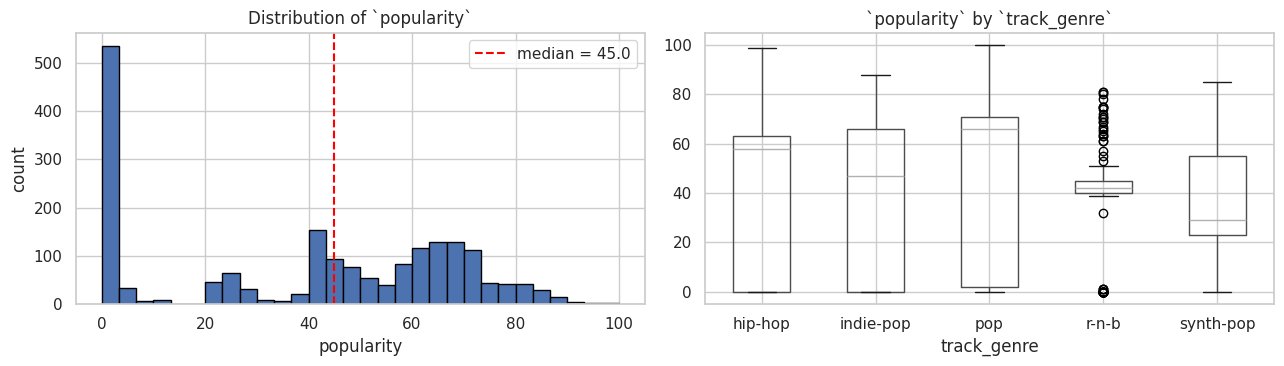

In [8]:
m = df["popularity"].median()
zero_count = int((df["popularity"] == 0).sum())
print(f"Median popularity m = {m}")
print(f"Tracks with popularity == 0: {zero_count} ({100*zero_count/len(df):.1f}%)")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].hist(df["popularity"], bins=30, edgecolor="black")
ax[0].axvline(m, color="red", linestyle="--", label=f"median = {m}")
ax[0].set(xlabel="popularity", ylabel="count", title="Distribution of `popularity`")
ax[0].legend()

df.boxplot(column="popularity", by="track_genre", ax=ax[1])
ax[1].set(title="`popularity` by `track_genre`", xlabel="track_genre")
plt.suptitle("")
plt.tight_layout()
plt.show()

**Observations.**

- A large spike at `popularity = 0`. Our interpretation (not directly verifiable from the data) is that these are more plausibly "no popularity data available" placeholders than truly unpopular tracks — a 21% zero spike on a Spotify dataset where the median is 45 is hard to explain otherwise. They all collapse into class 0 after binarisation, which makes class 0 partly a "low popularity OR unmeasured" mixture.
- The five genres have visibly different popularity distributions (pop &gt; indie-pop, etc.). This is the strongest signal in the dataset and motivates the with-vs-without-genre sensitivity later.

In [9]:
# Binarise the target. Per spec §3.3: drop the original `popularity` column afterwards.
df["popularity_binary"] = (df["popularity"] > m).astype(int)
df = df.drop(columns=["popularity"])

class_counts = df["popularity_binary"].value_counts().sort_index()
print("Class balance:")
print(class_counts)
print((class_counts / class_counts.sum()).round(3).rename("proportion"))

Class balance:
popularity_binary
0    987
1    943
Name: count, dtype: int64
popularity_binary
0    0.511
1    0.489
Name: proportion, dtype: float64


Classes are near-balanced (~51 / 49) by construction of the median split. This:

- justifies F1 as the primary metric (balance, but not perfect — F1 still surfaces P/R asymmetry within a model),
- means accuracy is *meaningful* on its own,
- means PR-AUC isn't strictly necessary (it's preferred for *imbalanced* data; ours isn't).

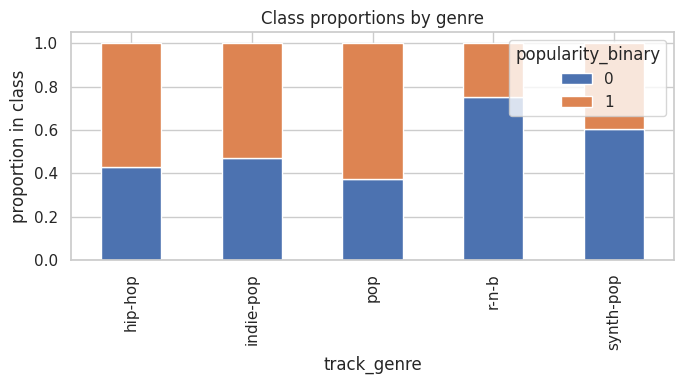

popularity_binary,0,1
track_genre,,
hip-hop,0.432,0.568
indie-pop,0.469,0.531
pop,0.375,0.625
r-n-b,0.751,0.249
synth-pop,0.607,0.393


In [10]:
# How separable do the genres look in terms of class distribution?
ct = pd.crosstab(df["track_genre"], df["popularity_binary"], normalize="index")
ax = ct.plot.bar(stacked=True, figsize=(7, 4))
ax.set_ylabel("proportion in class")
ax.set_title("Class proportions by genre")
ax.legend(title="popularity_binary", loc="upper right")
plt.tight_layout()
plt.show()
ct.round(3)

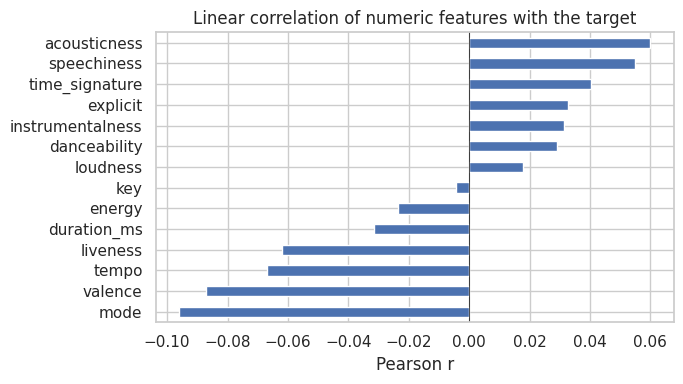

In [11]:
# Linear correlation of numeric features with the binary target.
numeric_cols = df.select_dtypes(include=[np.number]).columns
corrs = (
    df[numeric_cols].corr()["popularity_binary"]
    .drop("popularity_binary").sort_values()
)

fig, ax = plt.subplots(figsize=(7, 4))
corrs.plot.barh(ax=ax)
ax.set(xlabel="Pearson r", title="Linear correlation of numeric features with the target")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

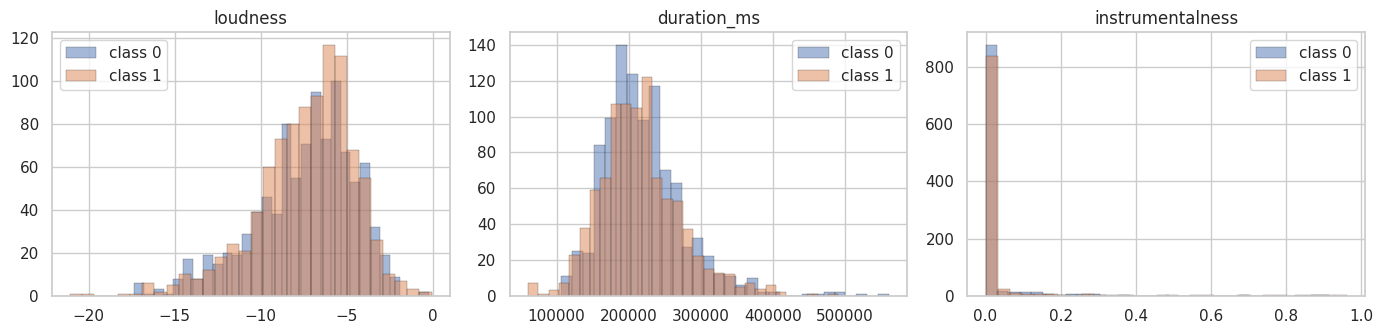

In [12]:
# Distributions of three example features by class — motivates the per-group preprocessing choices.
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, ["loudness", "duration_ms", "instrumentalness"]):
    for cls in [0, 1]:
        ax.hist(
            df.loc[df["popularity_binary"] == cls, col],
            bins=30, alpha=0.5, label=f"class {cls}", edgecolor="black", linewidth=0.3,
        )
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

These three columns illustrate the three numeric "shapes" we'll preprocess separately:

- `loudness` — unbounded with negative outliers (very-quiet tracks). `RobustScaler`.
- `duration_ms` — right-skewed, large outliers (long tracks). `RobustScaler`.
- `instrumentalness` — bounded [0, 1] but heavily concentrated near 0 (most tracks are vocal). `StandardScaler`.

## 3. Preprocessing pipeline

The project spec requires preprocessing to be done inside a pipeline so that transforms are fitted *per fold* during cross-validation (no leakage from validation rows back into the fit of imputers / scalers / encoders). `ColumnTransformer` lets us apply different transforms to different column groups inside a single pipeline.

| Group | Columns | Transformer | Why |
|---|---|---|---|
| Categorical (one-hot) | `track_genre`, `key`, `time_signature` | `OneHotEncoder(handle_unknown="ignore")` | Nominal — no ordering. `key` (chromatic 0-11) is nominal in pop context; `time_signature` is small-cardinality. |
| Binary passthrough | `mode`, `explicit` | `passthrough` | Already 0/1 after the cast. |
| Outlier-prone numeric | `duration_ms`, `loudness`, `tempo` | `RobustScaler` | Median/IQR-based; not pulled by outliers. |
| Bounded [0, 1] audio | `danceability`, `energy`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence` | `StandardScaler` | Centring helps kNN's distance metric and NB's Gaussian assumption; trees are scale-invariant but consistency keeps the pipeline simple. |

In [13]:
y = df["popularity_binary"]
X = df.drop(columns=["popularity_binary"])

categorical_cols       = ["track_genre", "key", "time_signature"]
binary_passthrough     = ["mode", "explicit"]
numeric_robust_cols    = ["duration_ms", "loudness", "tempo"]
numeric_standard_cols  = ["danceability", "energy", "speechiness", "acousticness",
                          "instrumentalness", "liveness", "valence"]

# Sanity: every column accounted for, no overlaps.
all_cols = categorical_cols + binary_passthrough + numeric_robust_cols + numeric_standard_cols
assert set(all_cols) == set(X.columns), "column list mismatch"
assert len(all_cols) == len(set(all_cols)), "column listed more than once"

preprocess = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("binary",      "passthrough",                                                binary_passthrough),
        ("num_robust",  RobustScaler(),                                               numeric_robust_cols),
        ("num_std",     StandardScaler(),                                             numeric_standard_cols),
    ],
    sparse_threshold=0,  # GaussianNB requires dense input
)
preprocess

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_

## 4. Train / test split

80 / 20, stratified on the target so each class is represented in approximately equal proportions in both partitions. The test set is reserved for a single final evaluation.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE,
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print("Train class balance:", y_train.value_counts().to_dict())
print("Test class balance :", y_test.value_counts().to_dict())

Train shape: (1544, 15), Test shape: (386, 15)
Train class balance: {0: 790, 1: 754}
Test class balance : {0: 197, 1: 189}


## 5. Single Decision Tree baseline (foil)

Before grid-searching Random Forest, we fit a single unconstrained `DecisionTreeClassifier` to demonstrate the high-variance / overfitting behaviour expected from a deep single tree. This isn't a candidate model — it just motivates the *ensembling* step.

In [15]:
dt_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("dt",         DecisionTreeClassifier(random_state=RANDOM_STATE)),
])
dt_pipe.fit(X_train, y_train)

cv_baseline = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
train_acc = dt_pipe.score(X_train, y_train)
cv_acc    = cross_val_score(dt_pipe, X_train, y_train, cv=cv_baseline, scoring="accuracy", n_jobs=-1).mean()

print(f"Single DT — train accuracy   : {train_acc:.3f}")
print(f"Single DT — 10-fold CV accuracy: {cv_acc:.3f}")
print(f"Generalisation gap            : {train_acc - cv_acc:.3f}")

Single DT — train accuracy   : 0.996
Single DT — 10-fold CV accuracy: 0.686
Generalisation gap            : 0.310


The single tree fits the training set near-perfectly but generalises far worse — the classic high-variance / overfitting pattern of unconstrained decision trees. Random Forest below is the principled fix: bagging averages over many decorrelated trees to reduce variance without raising bias.

## 6. Tuned classifiers

10-fold stratified CV, multi-metric reporting, refit on F1.

In [16]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "Accuracy":  "accuracy",
    "F1-score":  "f1",
    "Precision": "precision",
    "Recall":    "recall",
    "ROC_AUC":   "roc_auc",
    "AP":        "average_precision",
}

### 6.1 Random Forest

In [17]:
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf",         RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])
rf_grid = {
    "rf__n_estimators":     [200, 400],
    "rf__max_depth":        [None, 8, 16],
    "rf__max_features":     ["sqrt", 0.5],
    "rf__min_samples_leaf": [1, 3],
}
rf_search = GridSearchCV(
    rf_pipe, rf_grid, cv=cv, scoring=scoring, refit="F1-score",
    n_jobs=-1, return_train_score=False,
)
rf_search.fit(X_train, y_train)
print(f"Random Forest — best CV F1 = {rf_search.best_score_:.3f}")
print("Best params:", rf_search.best_params_)

Random Forest — best CV F1 = 0.716
Best params: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__n_estimators': 400}


### 6.2 k-Nearest Neighbours

In [18]:
knn_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("knn",        KNeighborsClassifier(n_jobs=-1)),
])
knn_grid = {
    "knn__n_neighbors": [5, 11, 21, 41, 81],
    "knn__weights":     ["uniform", "distance"],
    "knn__p":           [1, 2],   # Manhattan vs Euclidean
}
knn_search = GridSearchCV(
    knn_pipe, knn_grid, cv=cv, scoring=scoring, refit="F1-score",
    n_jobs=-1, return_train_score=False,
)
knn_search.fit(X_train, y_train)
print(f"k-NN — best CV F1 = {knn_search.best_score_:.3f}")
print("Best params:", knn_search.best_params_)

k-NN — best CV F1 = 0.638
Best params: {'knn__n_neighbors': 5, 'knn__p': 2, 'knn__weights': 'distance'}


### 6.3 Gaussian Naïve Bayes

In [19]:
gnb_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("gnb",        GaussianNB()),
])
gnb_grid = {
    "gnb__var_smoothing": np.logspace(-12, -6, 7),
}
gnb_search = GridSearchCV(
    gnb_pipe, gnb_grid, cv=cv, scoring=scoring, refit="F1-score",
    n_jobs=-1, return_train_score=False,
)
gnb_search.fit(X_train, y_train)
print(f"Gaussian NB — best CV F1 = {gnb_search.best_score_:.3f}")
print("Best params:", gnb_search.best_params_)

Gaussian NB — best CV F1 = 0.632
Best params: {'gnb__var_smoothing': np.float64(1e-12)}


## 7. Cross-validated comparison (training set only)

For each tuned model, we report mean ± std across 10 CV folds for all six metrics. The test set is *not* used here.

In [20]:
models = {
    "Random Forest": rf_search.best_estimator_,
    "k-NN":          knn_search.best_estimator_,
    "Gaussian NB":   gnb_search.best_estimator_,
}

cv_results = {}
for name, model in models.items():
    res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {m: res[f"test_{m}"] for m in scoring.keys()}

summary = pd.DataFrame({
    name: {m: f"{np.mean(v):.3f} ± {np.std(v):.3f}" for m, v in d.items()}
    for name, d in cv_results.items()
}).T
summary

,Accuracy,F1-score,Precision,Recall,ROC_AUC,AP
Random Forest,0.722 ± 0.034,0.716 ± 0.039,0.712 ± 0.033,0.722 ± 0.057,0.800 ± 0.042,0.771 ± 0.055
k-NN,0.675 ± 0.035,0.638 ± 0.040,0.700 ± 0.043,0.588 ± 0.046,0.737 ± 0.045,0.702 ± 0.056
Gaussian NB,0.597 ± 0.035,0.632 ± 0.030,0.571 ± 0.030,0.708 ± 0.041,0.618 ± 0.047,0.567 ± 0.044


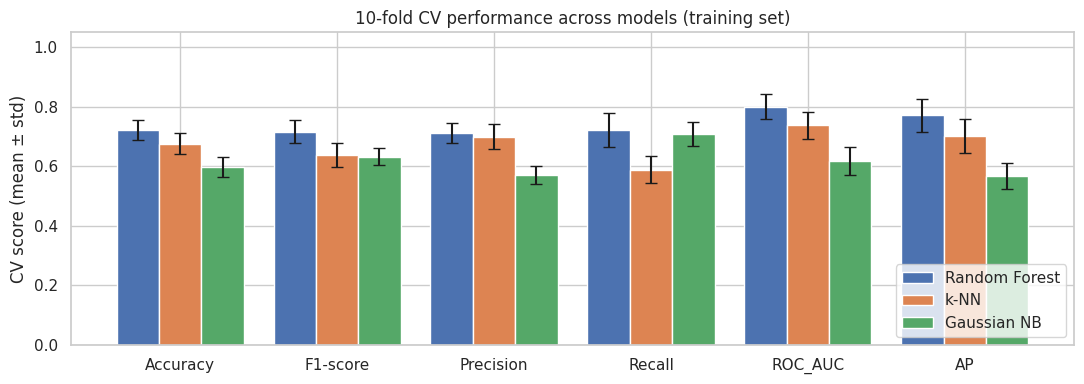

In [21]:
metric_names = list(scoring.keys())
labels = list(cv_results.keys())
x = np.arange(len(metric_names))
width = 0.27

fig, ax = plt.subplots(figsize=(11, 4))
for i, lab in enumerate(labels):
    means = [np.mean(cv_results[lab][m]) for m in metric_names]
    stds  = [np.std (cv_results[lab][m]) for m in metric_names]
    ax.bar(x + (i - 1) * width, means, width, yerr=stds, capsize=4, label=lab)

ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.05)
ax.set_ylabel("CV score (mean ± std)")
ax.set_title("10-fold CV performance across models (training set)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

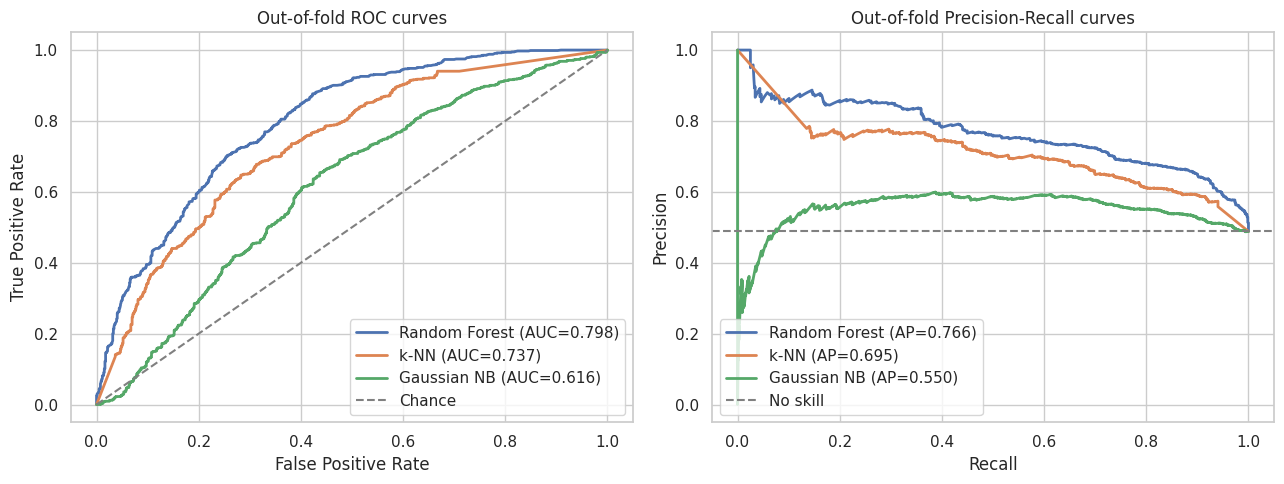

In [22]:
# Out-of-fold ROC and PR curves (each prediction comes from a model that did not train on that example).
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, model in models.items():
    proba = cross_val_predict(model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    fpr, tpr, _ = roc_curve(y_train, proba)
    axes[0].plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc(fpr, tpr):.3f})")
    p, r, _ = precision_recall_curve(y_train, proba)
    axes[1].plot(r, p, lw=2, label=f"{name} (AP={average_precision_score(y_train, proba):.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Chance")
axes[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="Out-of-fold ROC curves")
axes[0].legend(loc="lower right")

axes[1].axhline(y_train.mean(), linestyle="--", color="grey", label="No skill")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Out-of-fold Precision-Recall curves")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

## 8. Final model selection

Pick the candidate with the highest mean CV F1. The selected model is already refit on the full training set (that's what `GridSearchCV(..., refit="F1-score").best_estimator_` returns).

In [23]:
best_name  = max(models, key=lambda n: np.mean(cv_results[n]["F1-score"]))
best_model = models[best_name]
best_step  = list(best_model.named_steps.keys())[-1]   # "rf", "knn", or "gnb"
best_f1    = np.mean(cv_results[best_name]["F1-score"])
print(f"Selected model: {best_name} (mean CV F1 = {best_f1:.3f})")

Selected model: Random Forest (mean CV F1 = 0.716)


## 9. Sensitivity: with vs without `track_genre`

How much of the predictive power comes from genre alone? We re-evaluate the *winning* model on the same training data with `track_genre` removed, using the same hyperparameters.

In [24]:
preprocess_no_genre = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["key", "time_signature"]),
        ("binary",      "passthrough",                                                binary_passthrough),
        ("num_robust",  RobustScaler(),                                               numeric_robust_cols),
        ("num_std",     StandardScaler(),                                             numeric_standard_cols),
    ],
    sparse_threshold=0,
)

# Clone the winning classifier so we don't mutate `best_model`.
classifier = clone(best_model.named_steps[best_step])
sens_pipe  = Pipeline(steps=[("preprocess", preprocess_no_genre), (best_step, classifier)])

X_train_ng = X_train.drop(columns=["track_genre"])
ng_scores  = cross_validate(sens_pipe, X_train_ng, y_train, cv=cv, scoring=scoring, n_jobs=-1)

with_f1, with_acc = np.mean(cv_results[best_name]["F1-score"]), np.mean(cv_results[best_name]["Accuracy"])
ng_f1, ng_acc     = np.mean(ng_scores["test_F1-score"]),         np.mean(ng_scores["test_Accuracy"])

print(f"With genre    — CV F1 = {with_f1:.3f}, accuracy = {with_acc:.3f}")
print(f"Without genre — CV F1 = {ng_f1:.3f}, accuracy = {ng_acc:.3f}")
print(f"Δ F1 from removing genre: {ng_f1 - with_f1:+.3f}")

With genre    — CV F1 = 0.716, accuracy = 0.722
Without genre — CV F1 = 0.665, accuracy = 0.666
Δ F1 from removing genre: -0.051


**How to read this.** A large positive Δ (model gets much worse without genre) tells us that genre dominates the predictive signal — the model is essentially classifying *what kind of track this is* rather than *what makes a track popular*. A small Δ tells us audio features carry real complementary signal.

Either way, the trade-off is the same: keeping genre boosts the metric, but reduces the interpretive value of the audio-feature analysis.

## 10. Final evaluation on the held-out test set

Used **once**, after model selection.

In [25]:
def evaluate(model, Xe, ye):
    proba = model.predict_proba(Xe)[:, 1]
    pred  = model.predict(Xe)
    fpr, tpr, _ = roc_curve(ye, proba)
    p, r, _     = precision_recall_curve(ye, proba)
    return {
        "cm":        confusion_matrix(ye, pred),
        "accuracy":  accuracy_score(ye, pred),
        "precision": precision_score(ye, pred, zero_division=0),
        "recall":    recall_score(ye, pred, zero_division=0),
        "f1":        f1_score(ye, pred, zero_division=0),
        "fpr": fpr, "tpr": tpr, "auc": auc(fpr, tpr),
        "prc_p": p, "prc_r": r, "ap":  average_precision_score(ye, proba),
        "proba": proba, "pred": pred,
    }

test = evaluate(best_model, X_test, y_test)
print(f"--- Held-out test performance — {best_name} ---")
print(f"Accuracy : {test['accuracy']:.3f}")
print(f"Precision: {test['precision']:.3f}")
print(f"Recall   : {test['recall']:.3f}")
print(f"F1       : {test['f1']:.3f}")
print(f"ROC AUC  : {test['auc']:.3f}")
print(f"AP       : {test['ap']:.3f}")

--- Held-out test performance — Random Forest ---
Accuracy : 0.749
Precision: 0.750
Recall   : 0.730
F1       : 0.740
ROC AUC  : 0.790
AP       : 0.744


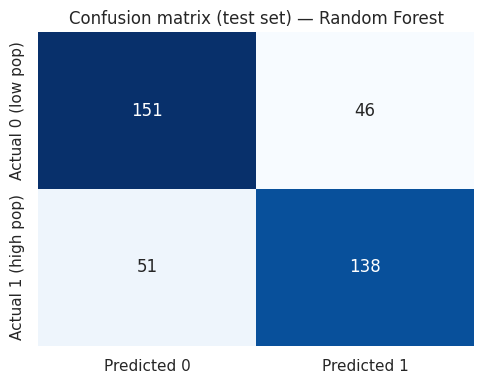

,Predicted 0,Predicted 1
Actual 0 (low pop),151,46
Actual 1 (high pop),51,138


In [26]:
cm_df = pd.DataFrame(
    test["cm"],
    index=["Actual 0 (low pop)", "Actual 1 (high pop)"],
    columns=["Predicted 0", "Predicted 1"],
)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title(f"Confusion matrix (test set) — {best_name}")
plt.tight_layout()
plt.show()
cm_df

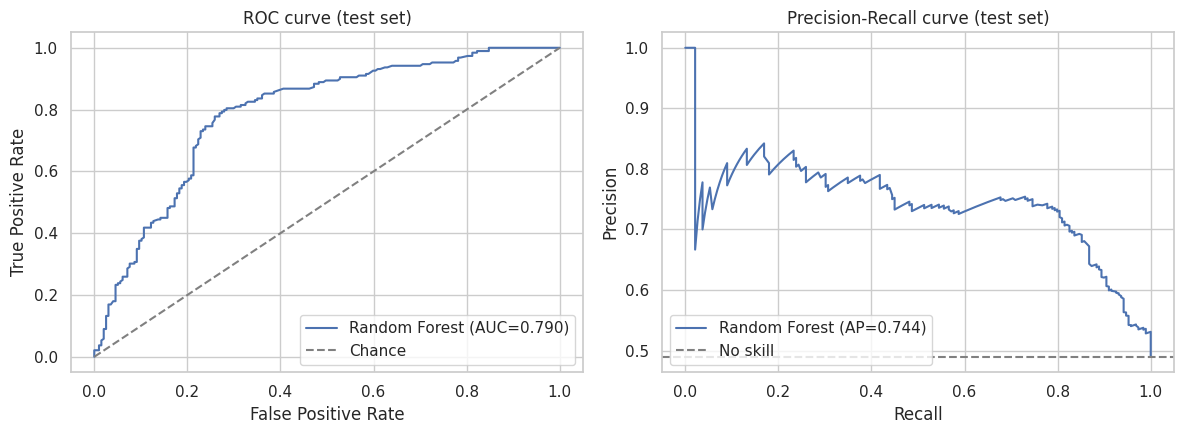

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(test["fpr"], test["tpr"], label=f"{best_name} (AUC={test['auc']:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color="grey", label="Chance")
axes[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC curve (test set)")
axes[0].legend(loc="lower right")

axes[1].plot(test["prc_r"], test["prc_p"], label=f"{best_name} (AP={test['ap']:.3f})")
axes[1].axhline(y_test.mean(), linestyle="--", color="grey", label="No skill")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall curve (test set)")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

## 11. Feature importance

The project spec asks us to analyse feature importance and interpret the results.

We use **permutation importance** as the model-agnostic measure (works for any winning model). When the winner is Random Forest, we additionally show the built-in `feature_importances_`, **aggregated by parent feature** so that `track_genre` isn't artificially fragmented across its one-hot dummies.

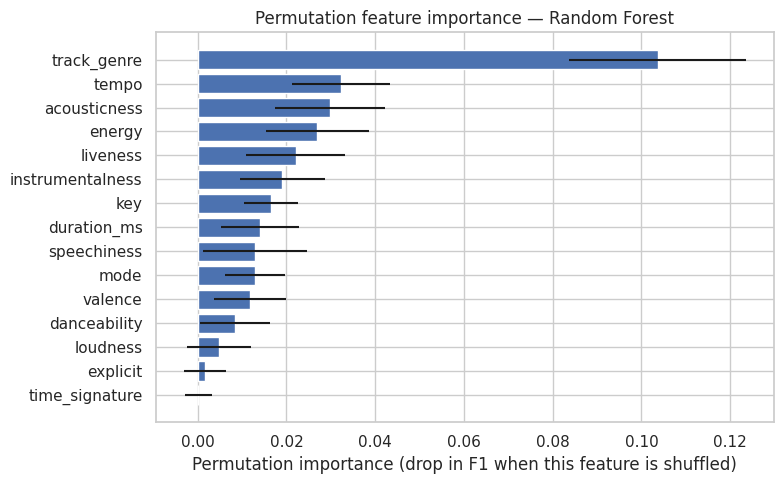

,feature,importance_mean,importance_std
0,track_genre,0.103612,0.019920
1,tempo,0.032261,0.011065
2,acousticness,0.029885,0.012424
3,energy,0.026940,0.011581
4,liveness,0.022094,0.011134
5,instrumentalness,0.019104,0.009562
6,key,0.016572,0.006044
7,duration_ms,0.014031,0.008809
8,speechiness,0.012921,0.011660
9,mode,0.012854,0.006705


In [28]:
# Permutation importance on the test set, scoring by F1 (our primary metric).
perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1, scoring="f1",
)
perm_df = pd.DataFrame({
    "feature":          X_test.columns,
    "importance_mean":  perm.importances_mean,
    "importance_std":   perm.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(perm_df["feature"], perm_df["importance_mean"], xerr=perm_df["importance_std"])
ax.invert_yaxis()
ax.set_xlabel("Permutation importance (drop in F1 when this feature is shuffled)")
ax.set_title(f"Permutation feature importance — {best_name}")
plt.tight_layout()
plt.show()
perm_df

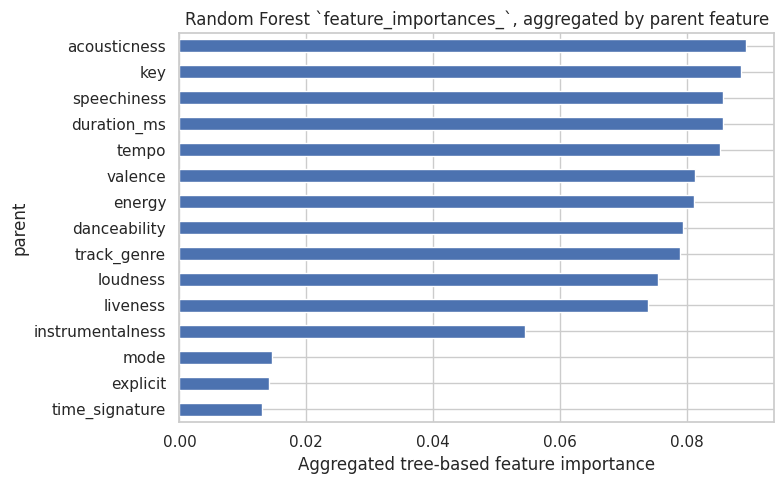

parent
acousticness        0.0892
key                 0.0884
speechiness         0.0856
duration_ms         0.0856
tempo               0.0852
valence             0.0812
energy              0.0811
danceability        0.0793
track_genre         0.0789
loudness            0.0753
liveness            0.0739
instrumentalness    0.0544
mode                0.0146
explicit            0.0142
time_signature      0.0131


In [29]:
# Tree-based importance, only meaningful if the winner is Random Forest.
if best_step == "rf":
    fitted_pre    = best_model.named_steps["preprocess"]
    feature_names = fitted_pre.get_feature_names_out()
    importances   = best_model.named_steps["rf"].feature_importances_

    def parent_of(name):
        # ColumnTransformer prefixes with the transformer name, e.g. "cat__track_genre_pop".
        rest = name.split("__", 1)[1] if "__" in name else name
        for parent in categorical_cols:
            if rest.startswith(parent + "_") or rest == parent:
                return parent
        return rest

    fi_df = pd.DataFrame({"feature": feature_names, "importance": importances})
    fi_df["parent"] = fi_df["feature"].apply(parent_of)
    agg = fi_df.groupby("parent")["importance"].sum().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    agg.plot.barh(ax=ax)
    ax.invert_yaxis()
    ax.set_xlabel("Aggregated tree-based feature importance")
    ax.set_title("Random Forest `feature_importances_`, aggregated by parent feature")
    plt.tight_layout()
    plt.show()
    print(agg.round(4).to_string())
else:
    print(f"Tree-based feature_importances_ not applicable for the chosen model ({best_name}).")

## 12. Save the trained model

Persisting the trained model with `pickle` lets it be reused (e.g. for re-evaluation, comparison with other notebooks, or future inference) without retraining.

In [30]:
with open("best_classifier.sav", "wb") as f:
    pickle.dump(best_model, f)
print(f"Saved {best_name} to best_classifier.sav")

Saved Random Forest to best_classifier.sav


## 13. Discussion

### Headline results

| Stage | Result |
|---|---|
| Single Decision Tree (foil) | Train acc **0.996** / CV acc **0.686** &rarr; **0.310 generalisation gap** |
| Random Forest (winner) | CV F1 **0.716** ± 0.039, test F1 **0.740**, ROC-AUC 0.790 |
| k-NN (2nd) | CV F1 0.638 |
| Gaussian NB (3rd) | CV F1 0.632 |
| RF without `track_genre` | CV F1 **0.665** (&Delta; = &minus;0.051) |

Random Forest wins on *every* reported metric &mdash; no contested cell. The DT&rarr;RF transition collapses a 31-percentage-point train-vs-CV gap into a healthy ~0.72 CV score: the textbook bias-variance shift from a single high-variance learner to a variance-reduced ensemble.

### Why each model placed where it did

- **Random Forest (CV F1 = 0.716, test F1 = 0.740).** Best params: `max_depth=None`, `max_features='sqrt'`, `min_samples_leaf=1`, `n_estimators=400`. The forest overcomes individual trees' overfitting by averaging over decorrelated trees &mdash; bootstrap resampling at the row level and random feature subsets at each split.
- **k-NN (CV F1 = 0.638).** Best at `n_neighbors=5`, `weights='distance'`, Euclidean distance (`p=2`). **Asymmetric profile**: precision **0.700**, recall **0.588**. kNN is *cautious* &mdash; when it predicts class 1 it's usually right, but it misses many true positives. Distance-weighting makes the closest neighbours dominate, which over-weights local noise.
- **Gaussian NB (CV F1 = 0.632).** Profile is the **opposite** of kNN: precision **0.571**, recall **0.708**. Over-eager to predict class 1. The independence assumption is violated by the audio features &mdash; the §3.1 EDA's correlation heatmap shows several correlated pairs: energy and loudness at &asymp;+0.63 (the strongest pair in the dataset), energy and acousticness at &asymp;&minus;0.59, and danceability and valence at &asymp;+0.38. High recall alone looks attractive, but the precision drop drags F1 below kNN.

### Confusion matrix on the test set

|             | Predicted 0 | Predicted 1 |
|---|---|---|
| Actual 0 (low pop)  | **151** (TN) | 46 (FP) |
| Actual 1 (high pop) | 51 (FN)      | **138** (TP) |

Errors are nearly symmetric (46 FP vs 51 FN). The chosen model isn't biased toward predicting one class &mdash; useful evidence that F1-refit selection worked: an asymmetric model would have lost on F1 even with the same accuracy.

### What features actually drive the prediction

Permutation importance on the test set (drop in F1 when each feature is shuffled, top of the ranking):

| Rank | Feature | Importance |
|---|---|---|
| 1 | `track_genre`     | **0.104** |
| 2 | `tempo`           | 0.032 |
| 3 | `acousticness`    | 0.030 |
| 4 | `energy`          | 0.027 |
| 5 | `liveness`        | 0.022 |
| 6 | `instrumentalness`| 0.019 |
| 7&ndash;11 | `key`, `duration_ms`, `speechiness`, `mode`, `valence` | 0.012 &ndash; 0.017 |
| 12&ndash;15 | `danceability`, `loudness`, `explicit`, `time_signature` | < 0.01 |

Four things stand out:

- **`track_genre` is roughly 3&times; the next feature** &mdash; by far the single most important predictor.
- **No single audio feature dominates** among the rest. Tempo, acousticness, energy, liveness, instrumentalness all contribute roughly equally, suggesting popularity is a combination of subtle audio signals rather than driven by one characteristic.
- **`loudness` ranks surprisingly low** despite being a much-discussed audio feature. The §3.1 EDA describe table shows the IQR is only &asymp;3.6&nbsp;dB wide ([&minus;8.99, &minus;5.39]), so most tracks sit in a narrow loudness band &mdash; which is *consistent with* the well-known "loudness war" in modern music mastering, though we can't verify that interpretation from this data alone.
- **`explicit` and `time_signature` contribute essentially nothing.** Only ≈11% of tracks are explicit and 4/4 dominates time signature, so both features have low variance and therefore low predictive value.

### Two importance methods, two stories

The notebook reports two feature-importance views. They disagree:

| Rank | Permutation importance | Tree-based importance (aggregated) |
|---|---|---|
| 1 | **`track_genre` (0.104)** | acousticness (0.089) |
| 2 | tempo (0.032) | key (0.088) |
| 3 | acousticness (0.030) | speechiness (0.086) |
| 4 | energy (0.027) | duration_ms (0.086) |
| 5 | liveness (0.022) | tempo (0.085) |
| &hellip; | &hellip; | &hellip; |
| 9 | speechiness (0.013) | **`track_genre` (0.079)** |

The tree-based view places `track_genre` at rank 9; the permutation view puts it at rank 1 with 3&times; the gap to the next feature. They can't both be right.

**Why the disagreement.** This is the well-known **bias of impurity-based importance toward high-cardinality / continuous features**. Trees draw far more split candidates from continuous features (acousticness, tempo, etc., each with hundreds of unique values) than from `track_genre`'s 5 categories &mdash; so impurity importance over-rewards features that offer more *split opportunities*, regardless of whether those splits are predictively useful. The scikit-learn documentation explicitly warns about this and recommends permutation importance as the unbiased alternative.

**Which view is correct.** The genre-sensitivity test in the next section settles it: *removing* `track_genre` costs 5 F1 points (more than removing any other single feature would). If `acousticness` were genuinely the most important feature, removing it would hurt more &mdash; but RF can substitute for any one missing audio feature by leaning on the rest. So the permutation ranking is the authoritative one for this dataset.

**Why we still report both.** The disagreement is itself a finding: it makes the impurity-bias issue visible in our actual data. Reporting only `feature_importances_` would have given a misleading picture (audio features look more important than they really are; genre looks irrelevant). The two-method cross-check is exactly what catches that.

### The `track_genre` sensitivity &mdash; modest, not dominant

| | CV F1 | CV accuracy |
|---|---|---|
| With `track_genre` | **0.716** | 0.722 |
| Without `track_genre` | **0.665** | 0.666 |
| &Delta; from removal | &minus;0.051 | &minus;0.056 |

This is the single most informative result in the notebook. The drop is real but modest &mdash; removing genre costs ~5 F1 points and the audio-feature-only model still reaches **0.665 F1**. So:

1. The model is **not** a "genre classifier in disguise." Most of the predictive signal lives in the audio features, with genre adding incremental value.
2. The audio features genuinely encode something popularity-relevant &mdash; they aren't decoration around a genre lookup.

Combined with the importance ranking (where genre is rank&nbsp;1 but with a finite gap to the next features), the picture is coherent: **genre is the single best predictor, but it's not doing the work alone.**

### The `popularity = 0` caveat

About 21% of cleaned tracks have `popularity = 0`. Our interpretation (not directly verifiable from the data) is that these are more plausibly *"no popularity data available"* placeholders than literal zero-stream tracks &mdash; a 21% zero spike on a Spotify dataset where the median is 45 is hard to explain otherwise. They all collapse into class 0, making class 0 a **"low popularity OR unmeasured"** mixture. This:

- inflates apparent class-0 accuracy (placeholder rows may correlate with metadata coverage),
- means the model can't separate "genuinely unpopular" from "missing measurement,"
- will be **far more damaging** in §3.4 regression (where the model has to predict 0 literally) than here, where any placeholder row landing in class 0 is technically "correct."

### Modelling decisions: what helped and what hurt

**A decision that *improved* performance.** Going from a single Decision Tree (CV accuracy 0.686 with a 0.310 gap from training &mdash; clear overfit) to a tuned Random Forest (CV F1 0.716, balanced precision / recall). The single tree memorised its training data; bagging many decorrelated trees recovered the generalisation.

**A decision that *hurt* &mdash; interpretively.** Keeping `track_genre`. It buys ~5 F1 points but blurs the academic question. The genre-sensitivity table above quantifies it: if we treat the model as "predicting popularity from audio features alone," it gets 0.665 F1; the extra 5 points from genre come from the model recognising that pop-genre tracks tend to chart higher.

### Methodology notes

- **k-NN's optimum was at the boundary of the grid** (`n_neighbors=5` was the smallest tested). A finer grid including `k=3` might shift kNN's score, but RF's lead (~8 F1 points) is too large to close without changing model architecture.
- **GNB's optimal `var_smoothing` was 1e-12** (also at the small end of the grid). This says regularisation didn't help &mdash; variance estimates were already well-conditioned. The real ceiling for GNB on this dataset is the violated independence assumption, not numerical issues.
- **Test F1 (0.740) slightly exceeds CV F1 (0.716).** Not unusual on a 386-row test split &mdash; the held-out set was marginally easier than the average CV fold. Both estimates point to the same range, so generalisation is healthy.